In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [152]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [153]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(f"Folder: {dirname}")
    print(f"Number of files: {len(filenames)}")
    print("-" * 60)

    if len(filenames) > 0:
        print("Sample files:")
        print(filenames[:5])
        print("=" * 60)

Folder: /kaggle/input
Number of files: 0
------------------------------------------------------------
Folder: /kaggle/input/datasets
Number of files: 0
------------------------------------------------------------
Folder: /kaggle/input/datasets/paramaggarwal
Number of files: 0
------------------------------------------------------------
Folder: /kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset
Number of files: 0
------------------------------------------------------------
Folder: /kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/fashion-dataset
Number of files: 2
------------------------------------------------------------
Sample files:
['images.csv', 'styles.csv']
Folder: /kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/fashion-dataset/images
Number of files: 44441
------------------------------------------------------------
Sample files:
['31973.jpg', '30778.jpg', '19812.jpg', '22735.jpg', '38246.jpg']
Folder: /kaggle/input/datase

In [156]:
import os

jpg_count = 0

for dirname, _, filenames in os.walk('/kaggle/input'):
    
    jpg_files = [f for f in filenames if f.lower().endswith('.jpg')]
    
    if len(jpg_files) > 0:
        print("\nFOUND IMAGE FOLDER:")
        print(dirname)
        print("Number of JPG files:", len(jpg_files))
        print("Sample Images:", jpg_files[:5])
        
        jpg_count += len(jpg_files)

print("\nTotal JPG Images Found:", jpg_count)


FOUND IMAGE FOLDER:
/kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/fashion-dataset/images
Number of JPG files: 44441
Sample Images: ['31973.jpg', '30778.jpg', '19812.jpg', '22735.jpg', '38246.jpg']

FOUND IMAGE FOLDER:
/kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/fashion-dataset/fashion-dataset/images
Number of JPG files: 44441
Sample Images: ['31973.jpg', '30778.jpg', '19812.jpg', '22735.jpg', '38246.jpg']

Total JPG Images Found: 88882


In [157]:
import os

base_path = "/kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/fashion-dataset"

print("Contents of fashion-dataset folder:")
print(os.listdir(base_path))

Contents of fashion-dataset folder:
['images.csv', 'images', 'styles.csv', 'styles', 'fashion-dataset']


In [158]:
import os

image_folder = "/kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/fashion-dataset/images"

files = os.listdir(image_folder)

print("Total files:", len(files))
print("\nFirst 10 files:")
print(files[:10])

Total files: 44441

First 10 files:
['31973.jpg', '30778.jpg', '19812.jpg', '22735.jpg', '38246.jpg', '16916.jpg', '52876.jpg', '39500.jpg', '44758.jpg', '59454.jpg']


In [159]:
import pandas as pd

csv_path = "/kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/fashion-dataset/styles.csv"

df = pd.read_csv(csv_path, on_bad_lines='skip')

print("Dataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape:
(44424, 10)

Columns:
['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName']

First 5 Rows:


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


In [160]:
print("Missing Values Per Column:\n")

print(df.isnull().sum())

Missing Values Per Column:

id                      0
gender                  0
masterCategory          0
subCategory             0
articleType             0
baseColour             15
season                 21
year                    1
usage                 317
productDisplayName      7
dtype: int64


In [161]:
article_counts = df['articleType'].value_counts()

print("Number of Unique Article Types:")
print(df['articleType'].nunique())

print("\nTop 20 Article Types:")
print(article_counts.head(20))

Number of Unique Article Types:
143

Top 20 Article Types:
articleType
Tshirts                  7067
Shirts                   3217
Casual Shoes             2845
Watches                  2542
Sports Shoes             2036
Kurtas                   1844
Tops                     1762
Handbags                 1759
Heels                    1323
Sunglasses               1073
Wallets                   936
Flip Flops                914
Sandals                   897
Briefs                    849
Belts                     813
Backpacks                 724
Socks                     686
Formal Shoes              637
Perfume and Body Mist     613
Jeans                     609
Name: count, dtype: int64


In [162]:
import os

# Image folder path
image_dir = "/kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/fashion-dataset/images"

# Top 15 classes
top_classes = df['articleType'].value_counts().head(15).index.tolist()

print("Top 15 Classes:")
print(top_classes)

# Keep only top 15 classes
df_filtered = df[df['articleType'].isin(top_classes)].copy()

# Create image path column
df_filtered['image_path'] = df_filtered['id'].astype(str) + ".jpg"

# Check if image exists
df_filtered['image_exists'] = df_filtered['image_path'].apply(
    lambda x: os.path.exists(os.path.join(image_dir, x))
)

# Keep only rows with existing images
df_filtered = df_filtered[df_filtered['image_exists']]

print("\nFiltered Dataset Shape:")
print(df_filtered.shape)

print("\nNumber of Classes:")
print(df_filtered['articleType'].nunique())

print("\nClass Distribution:")
print(df_filtered['articleType'].value_counts())

Top 15 Classes:
['Tshirts', 'Shirts', 'Casual Shoes', 'Watches', 'Sports Shoes', 'Kurtas', 'Tops', 'Handbags', 'Heels', 'Sunglasses', 'Wallets', 'Flip Flops', 'Sandals', 'Briefs', 'Belts']

Filtered Dataset Shape:
(29874, 12)

Number of Classes:
15

Class Distribution:
articleType
Tshirts         7066
Shirts          3215
Casual Shoes    2845
Watches         2542
Sports Shoes    2036
Kurtas          1844
Tops            1762
Handbags        1759
Heels           1323
Sunglasses      1073
Wallets          936
Flip Flops       914
Sandals          897
Briefs           849
Belts            813
Name: count, dtype: int64


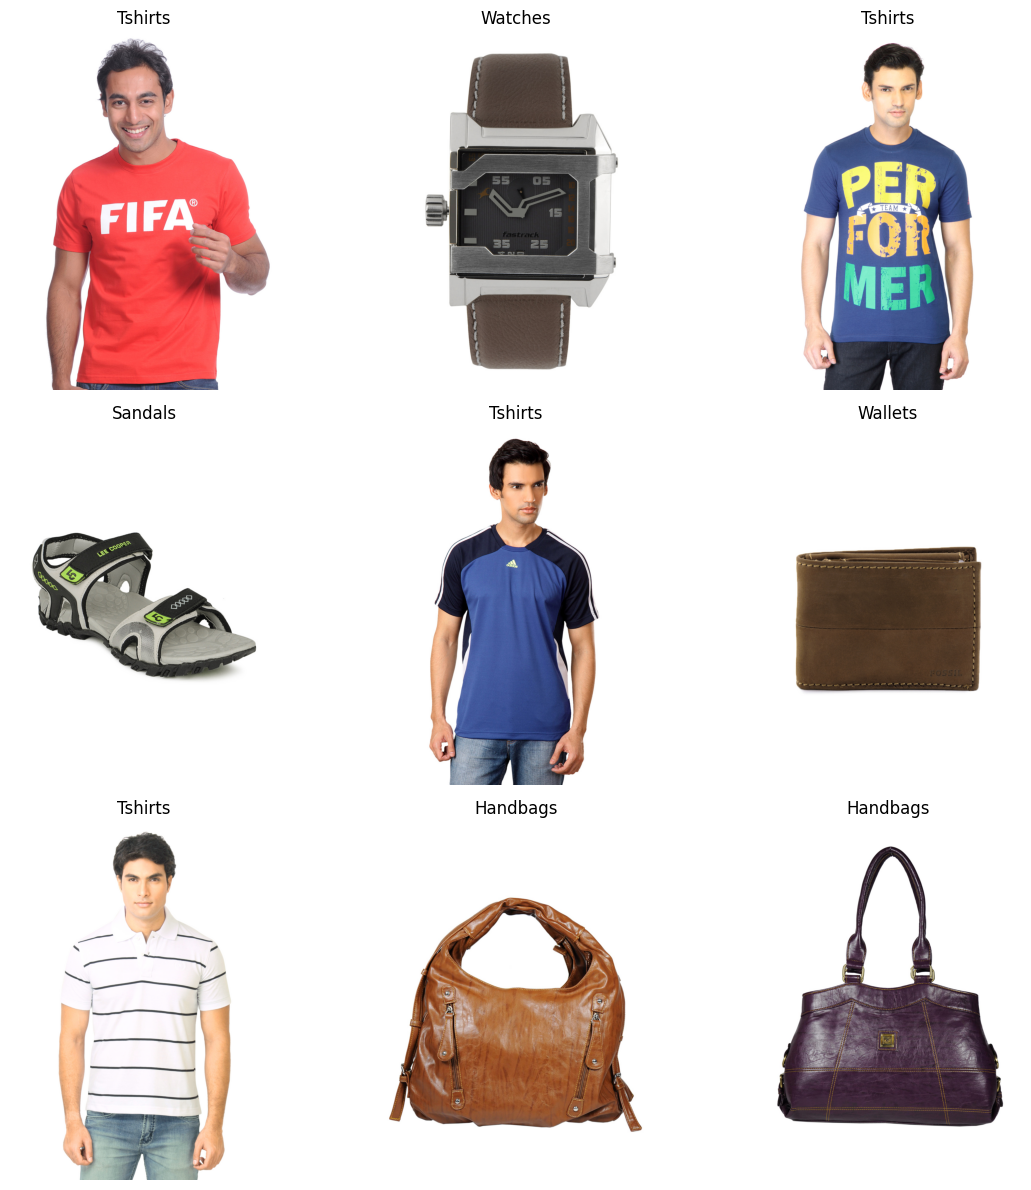

In [163]:
import matplotlib.pyplot as plt
from PIL import Image
import random

sample_df = df_filtered.sample(9, random_state=42)

plt.figure(figsize=(12, 12))

for i, (_, row) in enumerate(sample_df.iterrows()):
    
    img_path = os.path.join(
        image_dir,
        f"{row['id']}.jpg"
    )
    
    img = Image.open(img_path)

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(row['articleType'])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [164]:
from sklearn.model_selection import train_test_split

# First split: Train (70%) and Temp (30%)
train_df, temp_df = train_test_split(
    df_filtered,
    test_size=0.30,
    stratify=df_filtered['articleType'],
    random_state=42
)

# Second split: Validation (15%) and Test (15%)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['articleType'],
    random_state=42
)

print("Train Shape:", train_df.shape)
print("Validation Shape:", val_df.shape)
print("Test Shape:", test_df.shape)

print("\nTotal Records:")
print(len(train_df) + len(val_df) + len(test_df))

Train Shape: (20911, 12)
Validation Shape: (4481, 12)
Test Shape: (4482, 12)

Total Records:
29874


In [165]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

train_df['label'] = label_encoder.fit_transform(train_df['articleType'])

val_df['label'] = label_encoder.transform(val_df['articleType'])

test_df['label'] = label_encoder.transform(test_df['articleType'])

print("Number of Classes:", len(label_encoder.classes_))

print("\nClasses:")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"{i} --> {class_name}")

Number of Classes: 15

Classes:
0 --> Belts
1 --> Briefs
2 --> Casual Shoes
3 --> Flip Flops
4 --> Handbags
5 --> Heels
6 --> Kurtas
7 --> Sandals
8 --> Shirts
9 --> Sports Shoes
10 --> Sunglasses
11 --> Tops
12 --> Tshirts
13 --> Wallets
14 --> Watches


In [166]:
IMAGE_DIR = "/kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/fashion-dataset/images"

train_df['full_path'] = train_df['id'].apply(
    lambda x: f"{IMAGE_DIR}/{x}.jpg"
)

val_df['full_path'] = val_df['id'].apply(
    lambda x: f"{IMAGE_DIR}/{x}.jpg"
)

test_df['full_path'] = test_df['id'].apply(
    lambda x: f"{IMAGE_DIR}/{x}.jpg"
)

print("Train Sample:")
display(
    train_df[['id', 'articleType', 'label', 'full_path']].head()
)

Train Sample:


,id,articleType,label,full_path
7189,25498,Flip Flops,3,/kaggle/input/datasets/paramaggarwal/fashion-p...
26786,43953,Heels,5,/kaggle/input/datasets/paramaggarwal/fashion-p...
32956,24727,Casual Shoes,2,/kaggle/input/datasets/paramaggarwal/fashion-p...
38660,38765,Tshirts,12,/kaggle/input/datasets/paramaggarwal/fashion-p...
40967,30878,Kurtas,6,/kaggle/input/datasets/paramaggarwal/fashion-p...


In [167]:
import tensorflow as tf

IMG_SIZE = 224
BATCH_SIZE = 32

def load_image(path, label):
    
    image = tf.io.read_file(path)
    
    image = tf.image.decode_jpeg(image, channels=3)
    
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    
    image = image / 255.0
    
    return image, label


train_ds = tf.data.Dataset.from_tensor_slices(
    (train_df['full_path'].values,
     train_df['label'].values)
)

val_ds = tf.data.Dataset.from_tensor_slices(
    (val_df['full_path'].values,
     val_df['label'].values)
)

test_ds = tf.data.Dataset.from_tensor_slices(
    (test_df['full_path'].values,
     test_df['label'].values)
)

train_ds = train_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)

train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("TensorFlow datasets created successfully.")

TensorFlow datasets created successfully.


In [168]:
for images, labels in train_ds.take(1):
    
    print("Image Batch Shape:", images.shape)
    
    print("Label Batch Shape:", labels.shape)
    
    print("Image Data Type:", images.dtype)
    
    print("Label Data Type:", labels.dtype)

Image Batch Shape: (32, 224, 224, 3)
Label Batch Shape: (32,)
Image Data Type: <dtype: 'float32'>
Label Data Type: <dtype: 'int64'>


In [169]:
from tensorflow.keras import layers
from tensorflow.keras import Sequential

data_augmentation = Sequential([
    
    layers.RandomFlip("horizontal"),
    
    layers.RandomRotation(0.1),
    
    layers.RandomZoom(0.1)

])

print("Data Augmentation Pipeline Created Successfully")

Data Augmentation Pipeline Created Successfully


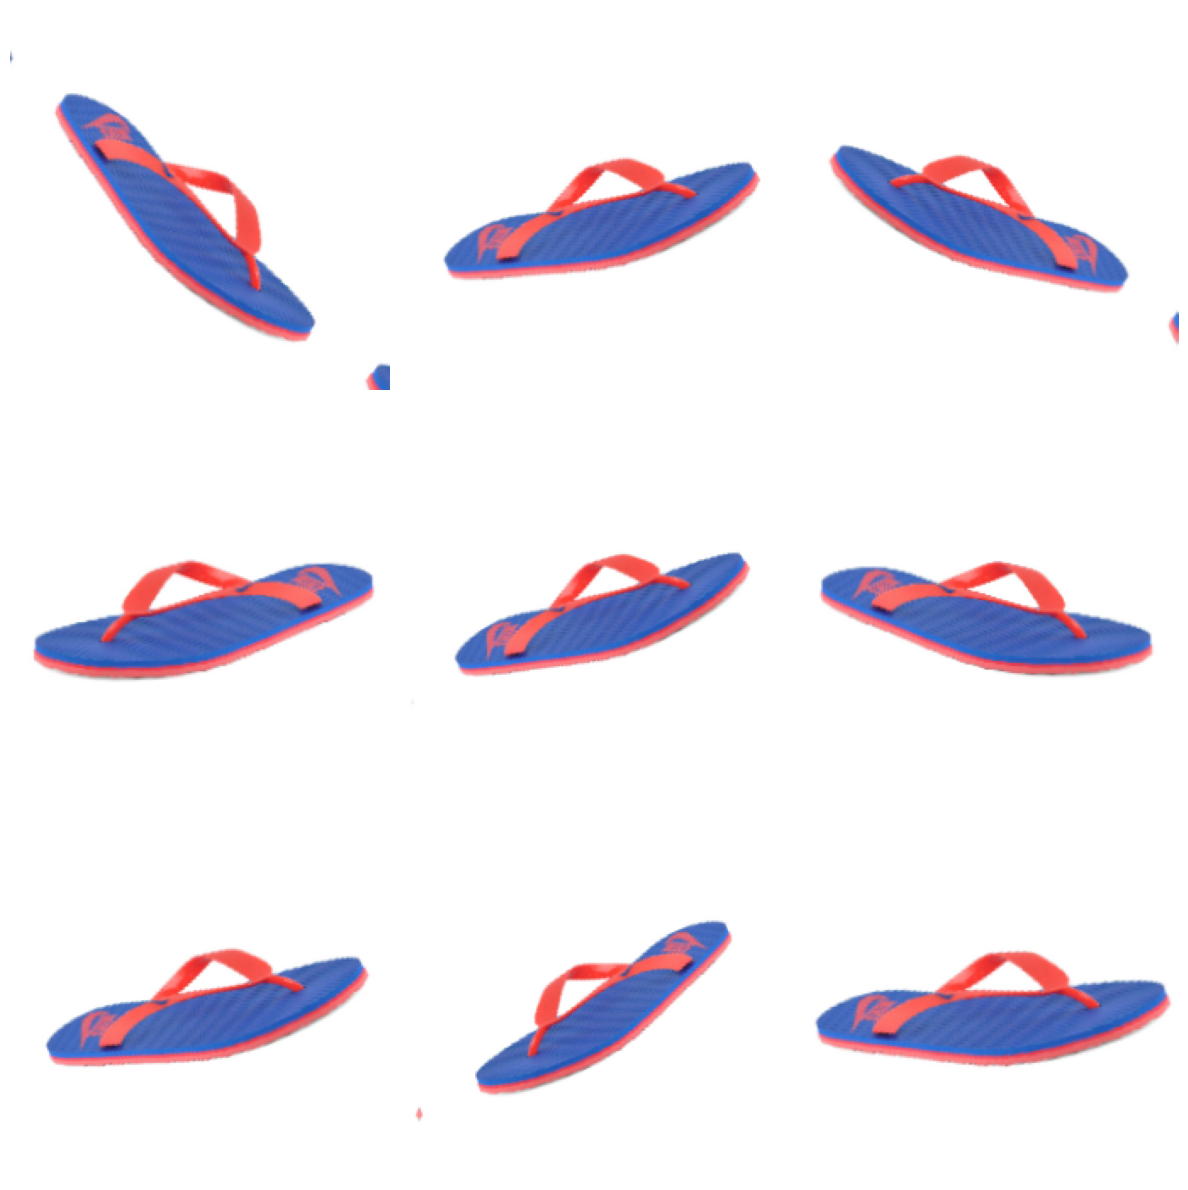

In [170]:
import matplotlib.pyplot as plt

for images, labels in train_ds.take(1):
    
    sample_image = images[0]
    
    plt.figure(figsize=(12, 12))
    
    for i in range(9):
        
        augmented_image = data_augmentation(
            tf.expand_dims(sample_image, 0)
        )
        
        ax = plt.subplot(3, 3, i + 1)
        
        plt.imshow(augmented_image[0])
        
        plt.axis("off")
    
    plt.tight_layout()
    
    plt.show()
    
    break

In [171]:
from tensorflow.keras import layers
from tensorflow.keras import models

NUM_CLASSES = len(label_encoder.classes_)

cnn_model = models.Sequential([

    layers.Input(shape=(224, 224, 3)),

    data_augmentation,

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),

    layers.Dropout(0.5),

    layers.Dense(NUM_CLASSES, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_5 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,248,527 (84.87 MB)

 Trainable params: 22,248,527 (84.87 MB)

 Non-trainable params: 0 (0.00 B)

In [172]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'best_cnn_model.keras',
    monitor='val_accuracy',
    save_best_only=True
)

print("Callbacks Created Successfully")

Callbacks Created Successfully


In [173]:
history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[
        early_stop,
        checkpoint
    ]
)

Epoch 1/10
 20/654 ━━━━━━━━━━━━━━━━━━━━ 2:00 190ms/step - accuracy: 0.1494 - loss: 3.7130

KeyboardInterrupt: 

In [238]:
test_loss, test_accuracy = cnn_model.evaluate(test_ds)

print("\nTest Loss:", test_loss)

print("Test Accuracy:", test_accuracy)

141/141 ━━━━━━━━━━━━━━━━━━━━ 26s 180ms/step - accuracy: 0.2365 - loss: 2.4347

Test Loss: 2.4346566200256348
Test Accuracy: 0.2365015596151352


In [176]:
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds:

    predictions = cnn_model.predict(images, verbose=0)

    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())

    y_pred.extend(predicted_labels)

print("Total Test Samples:", len(y_true))
print("Total Predictions:", len(y_pred))

Total Test Samples: 4482
Total Predictions: 4482


In [179]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

       Belts       0.00      0.00      0.00       122
      Briefs       0.00      0.00      0.00       127
Casual Shoes       0.00      0.00      0.00       427
  Flip Flops       0.00      0.00      0.00       137
    Handbags       0.00      0.00      0.00       264
       Heels       0.00      0.00      0.00       198
      Kurtas       0.00      0.00      0.00       277
     Sandals       0.00      0.00      0.00       134
      Shirts       0.00      0.00      0.00       482
Sports Shoes       0.00      0.00      0.00       306
  Sunglasses       0.00      0.00      0.00       161
        Tops       0.00      0.00      0.00       265
     Tshirts       0.24      1.00      0.38      1060
     Wallets       0.00      0.00      0.00       140
     Watches       0.00      0.00      0.00       382

    accuracy                           0.24      4482
   macro avg       0.02      0.07      0.03      4482
weighted avg       0.06   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


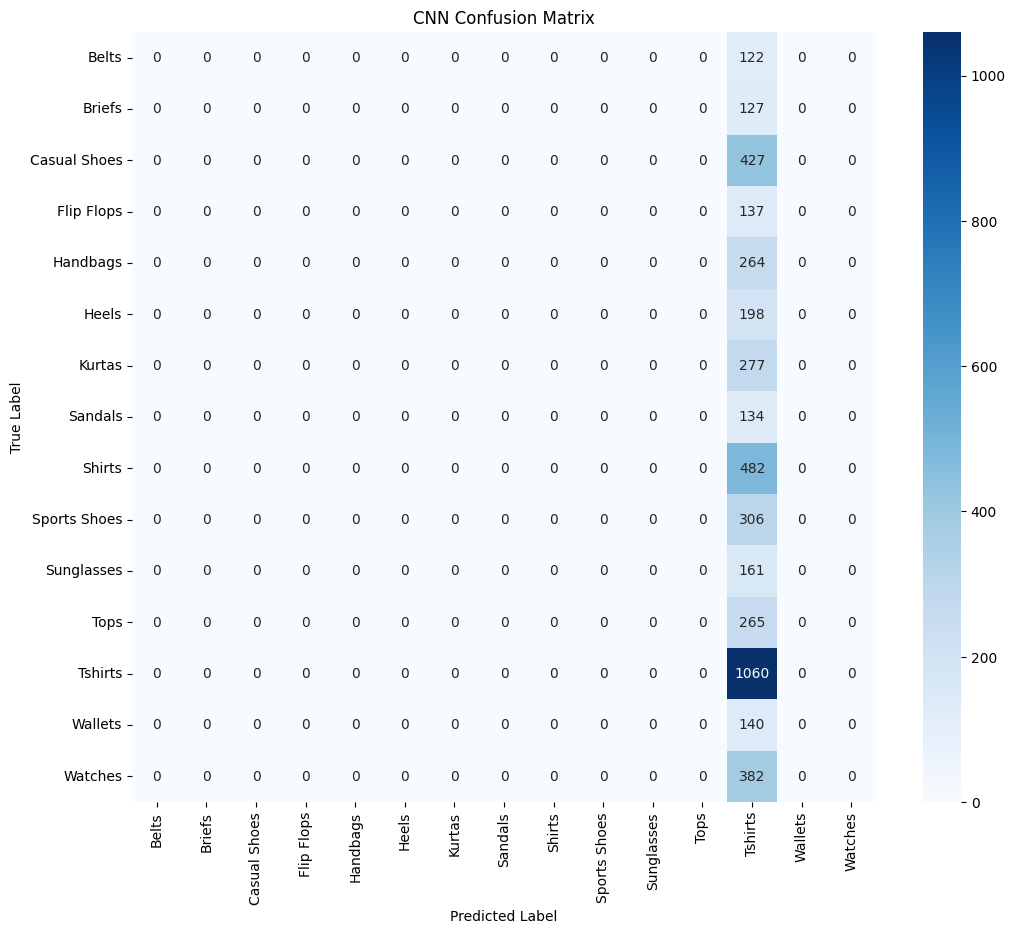

In [180]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("CNN Confusion Matrix")

plt.show()

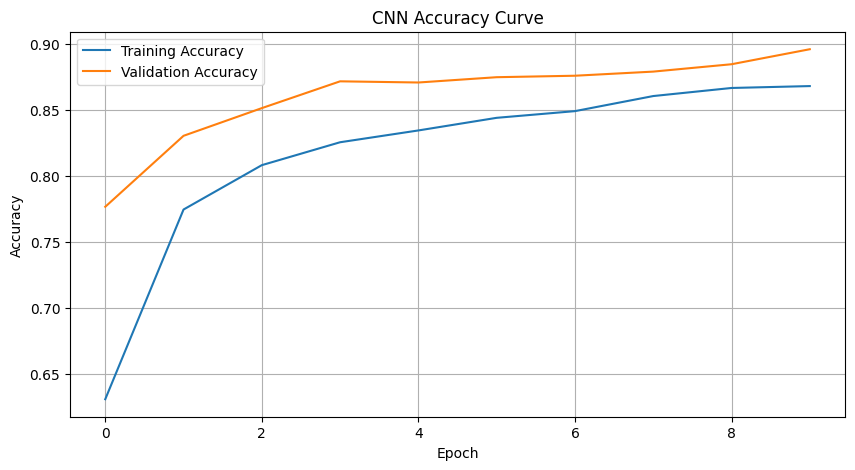

In [181]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('CNN Accuracy Curve')

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.legend()

plt.grid(True)

plt.show()

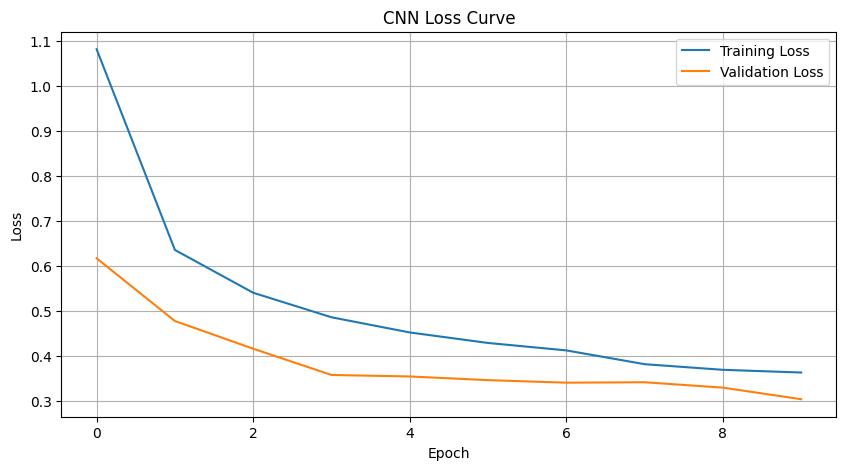

In [239]:
plt.figure(figsize=(10, 5))

plt.plot(history.history['loss'], label='Training Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('CNN Loss Curve')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend()

plt.grid(True)

plt.show()

In [240]:
import os

print(os.path.exists("cnn_model_final.keras"))

False


In [241]:
import pandas as pd

history_df = pd.DataFrame(history.history)

history_df.to_csv("cnn_training_history.csv", index=False)

print("History Saved")

History Saved


In [242]:
import os

print(os.path.exists("cnn_training_history.csv"))

True


In [243]:
print("cnn_model exists:", "cnn_model" in globals())
print("history exists:", "history" in globals())
print("train_ds exists:", "train_ds" in globals())
print("label_encoder exists:", "label_encoder" in globals())

cnn_model exists: True
history exists: True
train_ds exists: True
label_encoder exists: True


In [187]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze pretrained layers
base_model.trainable = False

efficientnet_model = models.Sequential([

    layers.Input(shape=(224, 224, 3)),

    data_augmentation,

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.3),

    layers.Dense(
        len(label_encoder.classes_),
        activation='softmax'
    )
])

efficientnet_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

efficientnet_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_5 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 15)             │        19,215 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,068,786 (15.52 MB)

 Trainable params: 19,215 (75.06 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [188]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

eff_early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

eff_checkpoint = ModelCheckpoint(
    'efficientnet_best.keras',
    monitor='val_accuracy',
    save_best_only=True
)

print("EfficientNet Callbacks Ready")

EfficientNet Callbacks Ready


In [189]:
import os

DATASET_PATH = "/kaggle/input"

for root, dirs, files in os.walk(DATASET_PATH):
    print(root)
    break

/kaggle/input


In [190]:
import os

print("Datasets inside /kaggle/input:\n")
print(os.listdir("/kaggle/input"))

Datasets inside /kaggle/input:

['datasets']


In [191]:
import os

base_path = "/kaggle/input/datasets"

print("Inside datasets folder:\n")
print(os.listdir(base_path))

Inside datasets folder:

['paramaggarwal']


In [192]:
import os

base_path = "/kaggle/input/datasets/paramaggarwal"

print("Top level inside dataset:\n")
print(os.listdir(base_path))

Top level inside dataset:

['fashion-product-images-dataset']


In [193]:
import os

base_path = "/kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset"

print("Inside dataset:\n")
print(os.listdir(base_path))

Inside dataset:

['fashion-dataset']


In [194]:
import os

base_path = "/kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/fashion-dataset"

print("Inside fashion-dataset:\n")
print(os.listdir(base_path))

Inside fashion-dataset:

['images.csv', 'images', 'styles.csv', 'styles', 'fashion-dataset']


In [195]:
import tensorflow as tf

tf.keras.backend.clear_session()

import gc
gc.collect()

print("Session cleaned for EfficientNetB0 pipeline")

Session cleaned for EfficientNetB0 pipeline


In [196]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print("EfficientNetB0 setup ready")
print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)

EfficientNetB0 setup ready
Image size: (224, 224)
Batch size: 32


In [197]:
import pandas as pd

base_path = "/kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset"

styles_path = f"{base_path}/styles.csv"

df = pd.read_csv(styles_path, on_bad_lines='skip')

print("Shape:", df.shape)
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/styles.csv'

In [198]:
import os

base_path = "/kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset"

for root, dirs, files in os.walk(base_path):
    if "styles.csv" in files:
        print("FOUND styles.csv at:")
        print(os.path.join(root, "styles.csv"))

FOUND styles.csv at:
/kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/fashion-dataset/styles.csv
FOUND styles.csv at:
/kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/fashion-dataset/fashion-dataset/styles.csv


In [202]:
import pandas as pd

base_path = "/kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/fashion-dataset"

styles_path = f"{base_path}/styles.csv"

df = pd.read_csv(styles_path, on_bad_lines='skip')

print("Shape:", df.shape)
print("\nColumns:", df.columns)
df.head()

Shape: (44424, 10)

Columns: Index(['id', 'gender', 'masterCategory', 'subCategory', 'articleType',
       'baseColour', 'season', 'year', 'usage', 'productDisplayName'],
      dtype='object')


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


In [203]:
import os

base_path = "/kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/fashion-dataset/images"

print("Images folder exists:", os.path.exists(base_path))

files = os.listdir(base_path)
print("Total files/folders in images:", len(files))
print("Sample:", files[:10])

Images folder exists: True
Total files/folders in images: 44441
Sample: ['31973.jpg', '30778.jpg', '19812.jpg', '22735.jpg', '38246.jpg', '16916.jpg', '52876.jpg', '39500.jpg', '44758.jpg', '59454.jpg']


In [204]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Input
from tensorflow.keras.models import Model

IMG_SIZE = (224, 224)

# Base EfficientNetB0 model (NO classification head)
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze base model (VERY IMPORTANT for stability)
base_model.trainable = False

# Build embedding model
inputs = Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)

embedding_model = Model(inputs, x)

print("EfficientNetB0 embedding model built successfully")
print("Output shape:", embedding_model.output_shape)

EfficientNetB0 embedding model built successfully
Output shape: (None, 1280)


In [206]:
import numpy as np
import cv2
import os
from tensorflow.keras.applications.efficientnet import preprocess_input

image_dir = "/kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/fashion-dataset/images"

def load_and_preprocess_image(image_id):
    img_path = os.path.join(image_dir, str(image_id) + ".jpg")
    
    # read image
    img = cv2.imread(img_path)
    
    if img is None:
        return None
    
    # convert BGR → RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # resize
    img = cv2.resize(img, (224, 224))
    
    # convert to array
    img = np.array(img)
    
    # IMPORTANT: EfficientNet preprocessing
    img = preprocess_input(img)
    
    return img

# test on one sample image
sample_id = df['id'].iloc[0]
test_img = load_and_preprocess_image(sample_id)

print("Sample ID:", sample_id)
print("Processed image shape:", test_img.shape)

Sample ID: 15970
Processed image shape: (224, 224, 3)


In [208]:
import numpy as np
from tqdm import tqdm

# use subset for safety (you can increase later)
subset_df = df.iloc[:5000].copy()

embeddings = []
valid_ids = []

for img_id in tqdm(subset_df['id']):
    img = load_and_preprocess_image(img_id)
    
    if img is not None:
        img = np.expand_dims(img, axis=0)  # batch dimension
        feature = embedding_model.predict(img, verbose=0)
        
        embeddings.append(feature[0])
        valid_ids.append(img_id)

embeddings = np.array(embeddings)

print("Embeddings shape:", embeddings.shape)
print("Valid images:", len(valid_ids))

100%|██████████| 5000/5000 [09:14<00:00,  9.02it/s]

Embeddings shape: (5000, 1280)
Valid images: 5000


In [215]:
from sklearn.metrics.pairwise import cosine_similarity

def get_similar_images(query_index, top_k=5):
    query_embedding = embeddings[query_index].reshape(1, -1)
    
    similarities = cosine_similarity(query_embedding, embeddings)[0]
    
    # get top matches (excluding itself)
    similar_indices = similarities.argsort()[-(top_k+1):][::-1]
    similar_indices = [i for i in similar_indices if i != query_index][:top_k]
    
    return similar_indices

In [216]:
import matplotlib.pyplot as plt
import cv2

image_dir = "/kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/fashion-dataset/images"

def show_images(image_ids, title="Similar Images"):
    plt.figure(figsize=(12, 4))
    
    for i, img_id in enumerate(image_ids):
        img_path = f"{image_dir}/{valid_ids[img_id]}.jpg"
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        plt.subplot(1, len(image_ids), i+1)
        plt.imshow(img)
        plt.axis("off")
    
    plt.suptitle(title)
    plt.show()

Query Image ID: 15970
Similar Image IDs: [19176, 19185, 8741, 16395, 15971]


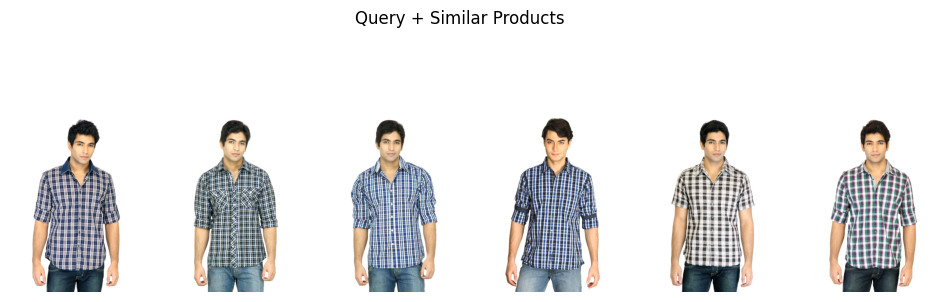

In [217]:
query_index = 0  # you can change this

similar_ids = get_similar_images(query_index, top_k=5)

print("Query Image ID:", valid_ids[query_index])
print("Similar Image IDs:", [valid_ids[i] for i in similar_ids])

show_images([query_index] + similar_ids, title="Query + Similar Products")

In [218]:
import numpy as np

embeddings_norm = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)

print("Normalization done")

Normalization done


In [219]:
from sklearn.metrics.pairwise import cosine_similarity

def get_similar_images(query_index, top_k=5):
    query_embedding = embeddings_norm[query_index].reshape(1, -1)
    
    similarities = cosine_similarity(query_embedding, embeddings_norm)[0]
    
    similar_indices = similarities.argsort()[-(top_k+1):][::-1]
    similar_indices = [i for i in similar_indices if i != query_index][:top_k]
    
    return similar_indices

Query: 15970
Similar: [19176, 19185, 8741, 16395, 15971]


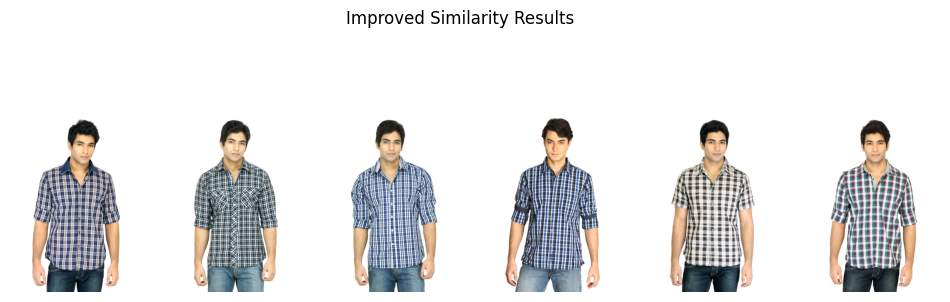

In [220]:
query_index = 0

similar_ids = get_similar_images(query_index)

print("Query:", valid_ids[query_index])
print("Similar:", [valid_ids[i] for i in similar_ids])

show_images([query_index] + similar_ids, title="Improved Similarity Results")

In [221]:
import faiss
import numpy as np

print("FAISS imported successfully")

FAISS imported successfully


In [222]:
!pip install faiss-cpu

In [244]:
import faiss
import numpy as np

print("FAISS imported successfully")

FAISS imported successfully


In [245]:
import numpy as np

# ensure correct type for FAISS
embeddings_np = embeddings_norm.astype('float32')

print("Shape:", embeddings_np.shape)
print("Dtype:", embeddings_np.dtype)

Shape: (5000, 1280)
Dtype: float32


In [246]:
import faiss

dimension = embeddings_np.shape[1]

index = faiss.IndexFlatIP(dimension)

index.add(embeddings_np)

print("FAISS index built successfully")
print("Total vectors indexed:", index.ntotal)

FAISS index built successfully
Total vectors indexed: 5000


In [229]:
def faiss_retrieve(query_index, top_k=5):
    query_vector = embeddings_np[query_index].reshape(1, -1)
    
    scores, indices = index.search(query_vector, top_k + 1)
    
    # remove itself from results
    results = [i for i in indices[0] if i != query_index][:top_k]
    
    return results

Query ID: 15970
FAISS Results: [19176, 19185, 8741, 16395, 15971]


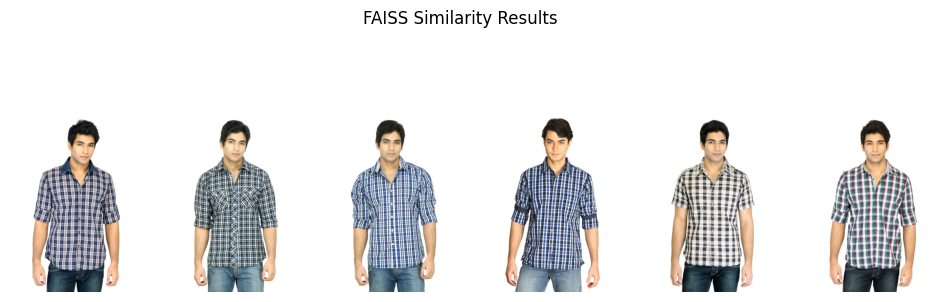

In [227]:
query_index = 0

results = faiss_retrieve(query_index)

print("Query ID:", valid_ids[query_index])
print("FAISS Results:", [valid_ids[i] for i in results])

show_images([query_index] + results, title="FAISS Similarity Results")

In [230]:
from sklearn.manifold import TSNE
import numpy as np

# use embeddings already created
X = embeddings_np[:2000]   # reduce for speed
labels = valid_ids[:2000]

print("Running t-SNE... this may take 1–3 minutes")

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init='random'
)

X_2d = tsne.fit_transform(X)

print("t-SNE completed")
print("Shape:", X_2d.shape)

Running t-SNE... this may take 1–3 minutes
t-SNE completed
Shape: (2000, 2)


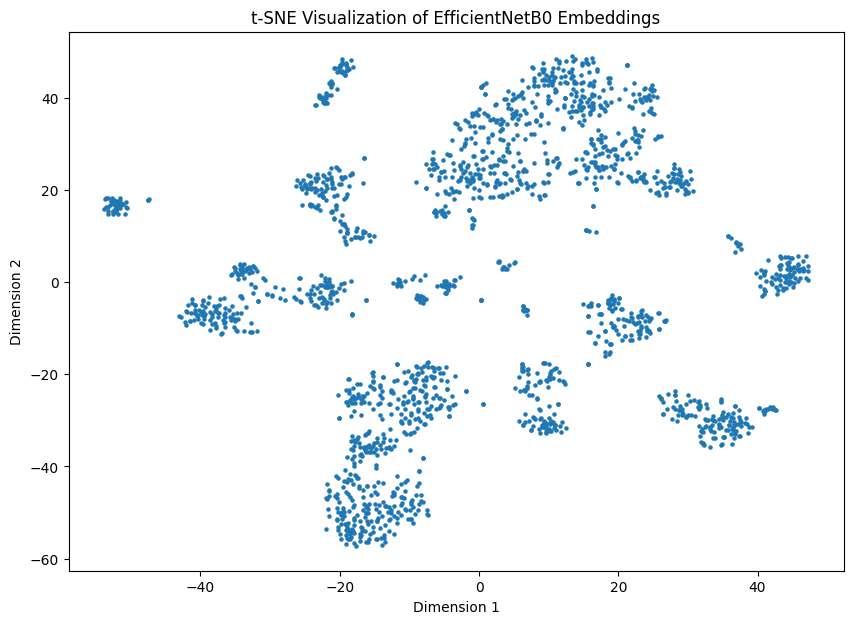

In [232]:
import matplotlib.pyplot as plt

subset_df = df.iloc[:2000].reset_index(drop=True)

plt.figure(figsize=(10, 7))
plt.scatter(X_2d[:, 0], X_2d[:, 1], s=5)

plt.title("t-SNE Visualization of EfficientNetB0 Embeddings")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")

plt.show()

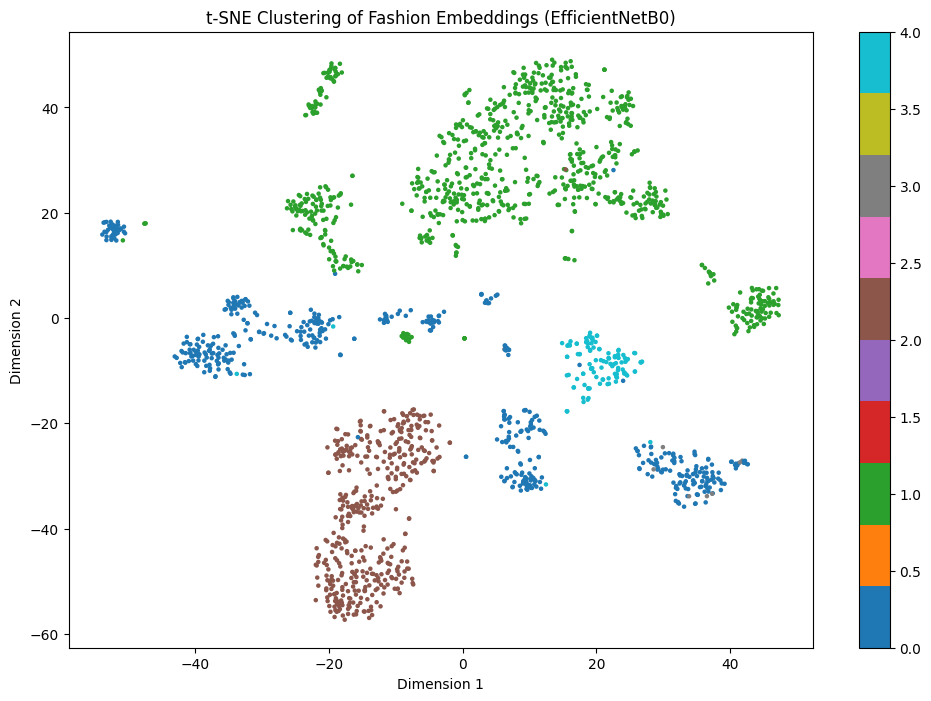

In [233]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

categories = subset_df['masterCategory'].astype('category').cat.codes

plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=categories,
    cmap='tab10',
    s=5
)

plt.title("t-SNE Clustering of Fashion Embeddings (EfficientNetB0)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")

plt.colorbar()
plt.show()

In [234]:
import pandas as pd
import numpy as np

# map id → category
id_to_category = dict(zip(df['id'], df['masterCategory']))

print("Mapping ready")

Mapping ready


In [235]:
def precision_at_k(query_index, top_k=5):
    query_id = valid_ids[query_index]

    query_category = id_to_category.get(query_id, None)

    if query_category is None:
        return None

    retrieved = faiss_retrieve(query_index, top_k)

    correct = 0

    for idx in retrieved:
        retrieved_id = valid_ids[idx]

        if id_to_category.get(retrieved_id) == query_category:
            correct += 1

    return correct / top_k


print("Precision@K function ready")

Precision@K function ready


In [236]:
sample_indices = np.random.choice(len(valid_ids), 200, replace=False)

scores = []

for i in sample_indices:
    score = precision_at_k(i, top_k=5)
    if score is not None:
        scores.append(score)

print("Average Precision@5:", np.mean(scores))

Average Precision@5: 0.9939999999999999


In [237]:
from collections import defaultdict

category_scores = defaultdict(list)

for i in sample_indices[:100]:
    query_id = valid_ids[i]
    query_category = id_to_category.get(query_id, None)
    
    retrieved = faiss_retrieve(i, 5)
    
    match = 0
    for r in retrieved:
        rid = valid_ids[r]
        if id_to_category.get(rid) == query_category:
            match += 1
    
    if query_category:
        category_scores[query_category].append(match / 5)

for cat, scores in category_scores.items():
    print(cat, "->", round(np.mean(scores), 3))

Accessories -> 0.97
Personal Care -> 1.0
Apparel -> 0.996
Footwear -> 1.0
